In [1]:
# import libraries
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential

In [2]:
# loading data
(x_train,y_train),(x_test,y_test) = keras.datasets.cifar10.load_data()

In [3]:
print(x_train.shape)
print(y_train.shape)

(50000, 32, 32, 3)
(50000, 1)


In [4]:
# normalization
x_train = x_train/255.0
x_test = x_test/255.0

### As RNN expects (batch,timesteps,features) we have to convert our data shape likewise


In [5]:
# reshape
x_train=x_train.reshape(-1,32,96)
x_test=x_test.reshape(-1,32,96)


y_train=y_train.reshape(-1)
y_test=y_test.reshape(-1)

In [12]:
# building model
model=keras.Sequential([
    keras.layers.Input(shape=(32,96)),
    keras.layers.LSTM(64, return_sequences=True),   # (return_sequences=True)- to add a LSTM sequence. 
    keras.layers.LSTM(128),                         # here weren't giving any sequence, so we are not giving anything.
    keras.layers.Dropout(0.3),
    keras.layers.Dense(128,activation='relu'),
    keras.layers.Dense(10,activation='softmax')
])

In [13]:
# compilation
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'])

In [14]:
# training model
hist= model.fit(x_train,y_train,epochs=35,validation_data=(x_test,y_test))

Epoch 1/35
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 50s 29ms/step - accuracy: 0.3367 - loss: 1.7985 - val_accuracy: 0.4139 - val_loss: 1.6200
Epoch 2/35
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 46s 29ms/step - accuracy: 0.4406 - loss: 1.5388 - val_accuracy: 0.4773 - val_loss: 1.4348
Epoch 3/35
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 47s 30ms/step - accuracy: 0.4875 - loss: 1.4181 - val_accuracy: 0.4999 - val_loss: 1.3802
Epoch 4/35
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 48s 31ms/step - accuracy: 0.5197 - loss: 1.3327 - val_accuracy: 0.5237 - val_loss: 1.3319
Epoch 5/35
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 49s 31ms/step - accuracy: 0.5434 - loss: 1.2636 - val_accuracy: 0.5450 - val_loss: 1.2687
Epoch 6/35
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 50s 32ms/step - accuracy: 0.5674 - loss: 1.2003 - val_accuracy: 0.5654 - val_loss: 1.2065
Epoch 7/35
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 50s 32ms/step - accuracy: 0.5894 - loss: 1.1459 - val_accuracy: 0.5815 - val_loss: 1.1666
Epoch 8/35
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 51s 33ms/step - accuracy: 0.6067 -

In [18]:
# evaluation
model.evaluate(x_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step - accuracy: 0.6119 - loss: 1.4096


[1.4095704555511475, 0.6118999719619751]

In [19]:
# prediction
predictions = model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 30ms/step


C:\Users\Prem\AppData\Local\Temp\ipykernel_4076\3058187466.py:6: UserWarning: Legend does not support handles for str instances.
A proxy artist may be used instead.
See: https://matplotlib.org/stable/users/explain/axes/legend_guide.html#controlling-the-legend-entries
  plt.legend(['accuracy'],['val_accuracy'])


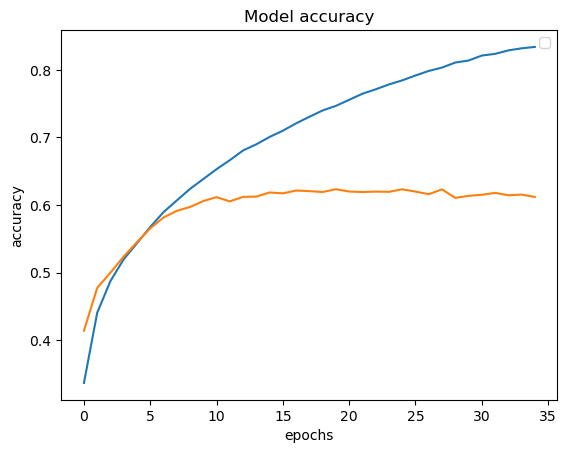

In [20]:
plt.plot(hist.history['accuracy'])
plt.plot(hist.history['val_accuracy'])
plt.xlabel('epochs')
plt.ylabel('accuracy')
plt.title('Model accuracy')
plt.legend(['accuracy'],['val_accuracy'])
plt.show()